## Prelude

Click "Run All" if notebook is not already populated with graphs.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from randomness import random
from fixed_point import fpi
from interpolations import interp
from integrals_roots import integrals

plt.rcParams['figure.figsize'] = [6.0, 3.8]  


## Pseudorandom Numbers

Among the methods for generating pseudorandom numbers with an equal solution is the Linear Congruential Generator, defined by the recursive function:

$$X_{n + 1} = (aX_{n} + c)\mod m$$

Where $m$, $a$, and $c$ are positive integers, $c$ and $m$ are coprime, $(a - 1)$ is a multiple of every prime factor of $m$ not equal to $m$, $m > a$ and $m > c$, and $X_0$ is some "seed" integer. (due to the $(a - 1)$ rule, $m$ is generally prime, but this is not strictly required)

The set of $\{X_{i}\}_{i \in N}$ where $N$ is the first $n$ positive integers is then a set of pseudorandom integers on the range $[0, m)$ with increment $c$ (hence why they have to be coprime to hit all possible integers on the range).

The function can be acheived computationally recursively fairly simply (where % is the modulo operator):

```python
def lcg(n):
    if n == 0:
        return x_0
    else:
        return (a * lcg(n - 1) + c) % m
```

The implimentation in the `task_one.py` script generates randomness using this equation where $m = 2^{16} + 1$, $a = 75$ and $c = 1$, and $X_0 = 1$, normalized to the range $[0, 1)$.

You can use the code block bellow generate psuedorandom numbers.

In [4]:
random.lcg()

0.0011596502738910844

Using these numbers, we can see that the lcg equation generates random numbers from $[0, 1)$ on an interval of $1 / (2^{16} + 1)$ (which averages to $2^{-16}$ with 32-bit floating-point error at runtime). There is no skewed distribution or obious correlation between consecutive numbers. You can plot the charts bellow:

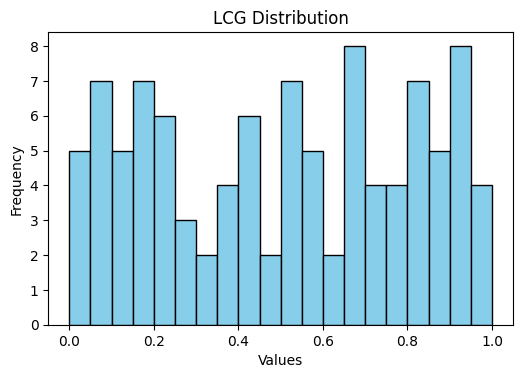

In [5]:
random.histogram(100)

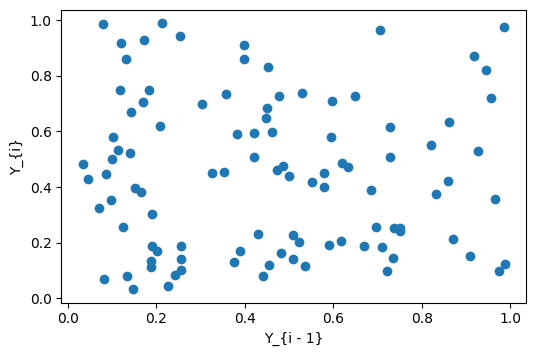

In [6]:
random.scatterplot(100)

But if we don't follow the rules stated above, that is not necissarily the case:

If $c$ and $m$ are not coprime, or $(a - 1)$ doesn't share prime factors with $m$, we get a stepwise linear output (the former leads to greater-than-one spacing, the ladder to correlation between consecutive outputs):

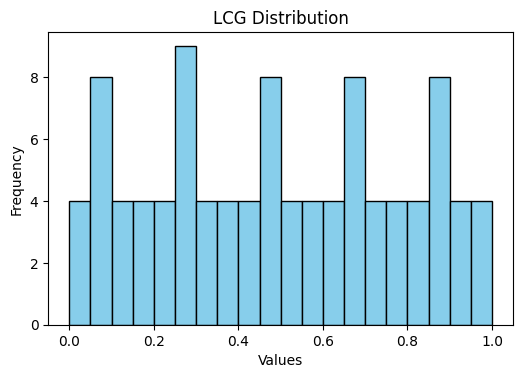

In [7]:
# c and m are not coprime:
random.histogram(100, m = 125, a = 6, c = 5)

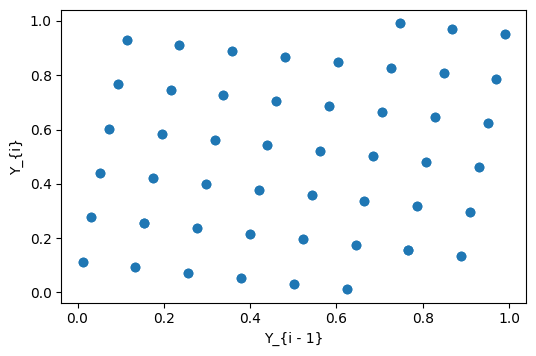

In [8]:
random.scatterplot(100, m = 343, a = 8, c = 7)

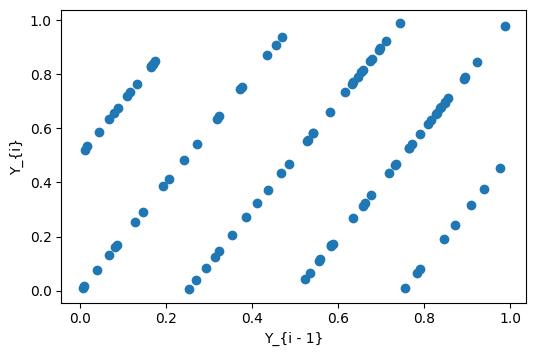

In [9]:
# (a - 1) doesn't share factors with m
random.scatterplot(100, m = 2018, a = 1011, c = 1)